# 05 · Prescriptive Optimization — Replenishment & Inter-Warehouse Transfers

**What we should do.** Turns Phase 3's diagnostics and Phase 4's predictive
signals into concrete, costed actions:

1. A **dynamic reorder recommendation** per SKU x Warehouse — order now or
   not, how much, how urgent — with the reorder point recomputed from the
   latest observed 90-day demand rather than the static generator-time
   policy table.
2. **Inter-warehouse transfer recommendations** — SKUs that are excess in
   one warehouse and short in another are matched with a small linear
   program (`scipy.optimize.linprog`) per SKU that minimizes total network
   cost: an internal transfer vs. a fresh, rush purchase order.

**A note on transfer cost, read before trusting the dollar figures:** the
real Brunel `FreightRates` table looks at first glance like exactly what a
transfer-cost matrix needs — but every lane in it terminates at one port
(PORT09). It's an *inbound* freight-rate card (cost to ship components INTO
the plants' receiving hub), not a plant-to-plant distribution network, so it
can't legitimately be repurposed as an any-to-any transfer-cost matrix.
Rather than force-fit data that doesn't fit, transfer cost here uses the
real per-warehouse `handling_cost_per_unit` (from Brunel WhCosts) at both
ends, plus an explicit, illustrative same-region/cross-region surcharge —
documented in `src/optimization_engine.py`, same spirit as the
`TARGET_DOS_BY_ABC` assumption in `kpi_engine.py`.

In [1]:
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = Path('/content/drive/MyDrive/inventory-intelligence-gsc')
except ImportError:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

import optimization_engine as oe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = PROJECT_ROOT / "data" / "processed" / "recommendations"
OUT_DIR.mkdir(parents=True, exist_ok=True)

inputs = oe.load_inputs(PROJECT_ROOT)
print("Loaded:", {k: v.shape for k, v in inputs.items()})

Loaded: {'health': (2035, 24), 'policy': (2035, 10), 'warehouse': (19, 4)}


## 1. Dynamic replenishment recommendation

Reorder point recomputed from the latest observed 90-day demand (not the static Phase 2 policy table), compared against current on-hand.

In [2]:
df = oe.compute_dynamic_replenishment(inputs["health"], inputs["policy"])
df = oe.compute_excess_and_shortage(df)

print(f"SKU x Warehouse rows evaluated: {len(df)}")
print()
print(df["recommended_action"].value_counts().to_string())
print()
print("Cross-check against Phase 4's Health Score tiers:")
print(pd.crosstab(df["health_tier"], df["recommended_action"]))

SKU x Warehouse rows evaluated: 2035

recommended_action
Monitor                           1412
Reduce / hold — excess stock       569
Order now                           32
Order now — high stockout risk      22

Cross-check against Phase 4's Health Score tiers:
recommended_action  Monitor  Order now  Order now — high stockout risk  \
health_tier                                                              
Critical                  0          0                               0   
Watch                   620         11                              15   
Healthy                 792         21                               7   

recommended_action  Reduce / hold — excess stock  
health_tier                                       
Critical                                      22  
Watch                                        544  
Healthy                                        3  


## 2. Transfer cost matrix

See the note above — built from real per-warehouse handling costs plus a documented regional surcharge, not the (unsuitable) Brunel freight-rate table.

In [3]:
cost_matrix = oe.build_transfer_cost_matrix(inputs["warehouse"])
print(cost_matrix.shape, "warehouse-pair lanes priced")
cost_matrix.sort_values("cost_per_unit").head(5)

(342, 3) warehouse-pair lanes priced


,from_warehouse,to_warehouse,cost_per_unit
332,PLANT04,PLANT07,1.299927
161,PLANT07,PLANT04,1.299927
158,PLANT07,PLANT13,1.341131
278,PLANT13,PLANT07,1.341131
287,PLANT13,PLANT04,1.398210


## 3. Inter-warehouse transfer optimization (linear program)

For every SKU present in 2+ warehouses with excess somewhere and a shortage somewhere else, solve a small transportation LP: minimize transfer cost + the cost of any shortage left over to cover with a fresh, rush PO (`PO_RUSH_PREMIUM_FRACTION` above the normal unit cost).

In [4]:
transfers = oe.optimize_transfers(df, cost_matrix)

print(f"Transfer recommendations: {len(transfers)} moves, "
      f"{transfers['transfer_qty'].sum() if len(transfers) else 0:.0f} units, "
      f"${transfers['total_cost'].sum() if len(transfers) else 0:,.2f} total transfer cost")
display(transfers)

Transfer recommendations: 2 moves, 2 units, $6.43 total transfer cost


,sku,from_warehouse,to_warehouse,transfer_qty,cost_per_unit,total_cost
0,1656889,PLANT05,PLANT02,1,2.97,2.96
1,1683409,PLANT03,PLANT02,1,3.00,3.47


## 4. Shortage that still needs a fresh PO

Some shortages have no matching excess anywhere in the network for that SKU — those go to a normal replenishment order, not a transfer.

In [5]:
matched_shortage = (transfers.groupby(["sku", "to_warehouse"])["transfer_qty"].sum()
                     if len(transfers) else pd.Series(dtype=float))
shortage_rows = df.loc[df["shortage_qty"] > 0, ["sku", "warehouse_id", "shortage_qty", "unit_cost"]].copy()
shortage_rows["matched_by_transfer"] = shortage_rows.apply(
    lambda r: matched_shortage.get((r["sku"], r["warehouse_id"]), 0.0), axis=1)
shortage_rows["unmet_via_fresh_po"] = (shortage_rows["shortage_qty"] - shortage_rows["matched_by_transfer"]).clip(lower=0).round(0)

print(f"Shortage requiring a fresh PO: {shortage_rows['unmet_via_fresh_po'].sum():.0f} units "
      f"across {(shortage_rows['unmet_via_fresh_po'] > 0).sum()} SKU x Warehouse rows")
shortage_rows.sort_values("unmet_via_fresh_po", ascending=False).head(10)

Shortage requiring a fresh PO: 154 units across 34 SKU x Warehouse rows


,sku,warehouse_id,shortage_qty,unit_cost,matched_by_transfer,unmet_via_fresh_po
1416,1690004,PLANT03,70.863144,30.25,0.0,71.0
738,1692708,PLANT16,10.170635,20.30,0.0,10.0
1577,1699285,PLANT03,7.785045,312.24,0.0,8.0
1327,1684647,PLANT03,6.434327,161.62,0.0,6.0
754,1696532,PLANT16,4.568362,62.99,0.0,5.0
243,1688294,PLANT02,4.889565,61.72,0.0,5.0
1704,1700298,PLANT03,3.697662,22.41,0.0,4.0
1801,1685293,PLANT13,4.417263,13.95,0.0,4.0
1795,1685286,PLANT13,4.254816,134.94,0.0,4.0
927,1689780,PLANT11,3.036476,425.00,0.0,3.0


## 5. Where the dollars are

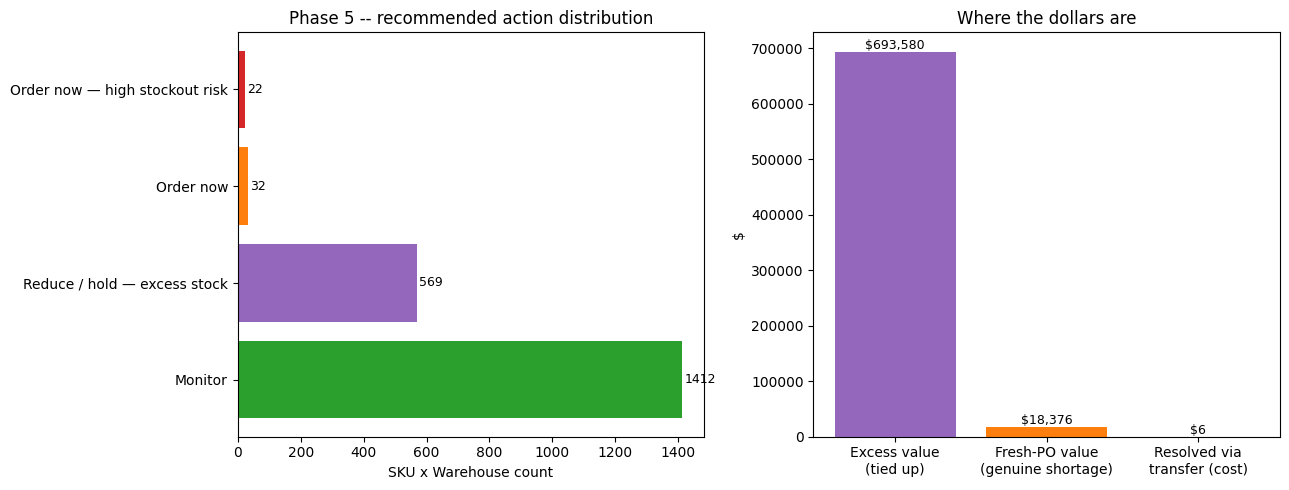

Excess value tied up: $693,580
Fresh-PO value (genuine shortage): $18,376
Cost of the 2 recommended transfers: $6.43


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

action_order = ["Order now — high stockout risk", "Order now", "Reduce / hold — excess stock", "Monitor"]
counts = df["recommended_action"].value_counts().reindex(action_order).fillna(0)
colors = ["#d62728", "#ff7f0e", "#9467bd", "#2ca02c"]
axes[0].barh(action_order[::-1], counts[::-1], color=colors[::-1])
axes[0].set_xlabel("SKU x Warehouse count")
axes[0].set_title("Phase 5 -- recommended action distribution")
for i, v in enumerate(counts[::-1]):
    axes[0].text(v + 8, i, f"{int(v)}", va="center", fontsize=9)

excess_value = df.loc[df["is_excess"], "excess_value"].sum()
unmet_value = (shortage_rows["unmet_via_fresh_po"] * shortage_rows["unit_cost"]).sum()
transfer_value = transfers["total_cost"].sum() if len(transfers) else 0
axes[1].bar(["Excess value\n(tied up)", "Fresh-PO value\n(genuine shortage)", "Resolved via\ntransfer (cost)"],
            [excess_value, unmet_value, transfer_value], color=["#9467bd", "#ff7f0e", "#2ca02c"])
axes[1].set_ylabel("$")
axes[1].set_title("Where the dollars are")
for i, v in enumerate([excess_value, unmet_value, transfer_value]):
    axes[1].text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "phase5_optimization_summary.png", dpi=130)
plt.show()

print(f"Excess value tied up: ${excess_value:,.0f}")
print(f"Fresh-PO value (genuine shortage): ${unmet_value:,.0f}")
print(f"Cost of the {len(transfers)} recommended transfers: ${transfer_value:,.2f}")

## Reading the result

The network's problem is concentrated excess ($693K, per Phase 3 — mostly
PLANT03), not scattered shortages. At this snapshot, only 54 of 2,035 SKU x
Warehouse rows are at or below their (freshly recomputed) reorder point.

The cross-tab against Phase 4's Health Score is worth a second look: all 22
"Critical" rows land under **"Reduce / hold — excess stock,"** not under a
reorder action. That's not a coincidence — it's the Health Score formula
correctly doing its job: severe, prolonged overstock drags the score down
just as much as stockout risk does, and on this network overstock is the
dominant problem. So "Critical" here means *"money badly stuck,"* not
*"about to run out"* — a distinction the AI Advisor (Phase 7) will need to
narrate correctly rather than default to "stockout" framing for every
Critical alert.

Of the 54 genuine reorder rows, only a handful of SKUs also have excess of
the *same* SKU sitting in another warehouse — so most route correctly to a
normal replenishment PO rather than an internal transfer. That's not a weak
optimization result; it's the model correctly declining to invent transfer
opportunities the network doesn't actually have, while still catching the
few it does.

## 6. Saved outputs

- `data/processed/recommendations/replenishment_recommendations.parquet`
- `data/processed/recommendations/transfer_recommendations.parquet`
- `data/processed/recommendations/unmet_shortage_fresh_po.parquet`
- `data/processed/recommendations/transfer_cost_matrix.parquet`
- `docs/phase5_optimization_summary.png`

Next: `06_powerbi_export` (Phase 6 — Power BI decision dashboard, built on the same star schema and these recommendation tables).

In [7]:
tables = {
    "replenishment_recommendations": df,
    "transfer_recommendations": transfers,
    "unmet_shortage_fresh_po": shortage_rows,
    "transfer_cost_matrix": cost_matrix,
}
for name, tdf in tables.items():
    tdf.to_parquet(OUT_DIR / f"{name}.parquet", index=False)
print("Saved:", list(tables.keys()))

Saved: ['replenishment_recommendations', 'transfer_recommendations', 'unmet_shortage_fresh_po', 'transfer_cost_matrix']
